## Data Scientist (DS)
### Module - 2 (Module-End Assignment)

#### Assignment Task Overview : Problem Statement
In this project, you will analyze an online retail dataset containing customer transactions, product
details, quantities, prices, and purchase dates.
Businesses use such data to understand sales trends, customer behavior, and product performance.
However, raw data requires cleaning, transformation, and analysis to generate meaningful insights.
You will build a data analysis pipeline using NumPy, Pandas, Matplotlib, and Seaborn to clean data,
perform analysis, visualize patterns, and derive actionable business insights.

#### Objective
● Clean and preprocess real-world data
● Perform exploratory data analysis (EDA)
● Create new features for analysis
● Visualize trends using charts
● Generate business insights

Dataset: Online Retail Dataset – UCI Repository

### Task 1 – Data Import & Setup
● Load dataset using Pandas 
● Explore structure: head(), tail(), shape, columns 
● Convert InvoiceDate to datetime

In [1]:

import pandas as pd 

data = pd.read_excel('C:\\Users\\jeeva\\Desktop\\learn to config git\\Online Retail.xlsx')  # Load dataset using Pandas
data  # Explore structure



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [2]:
data.head(4)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
data.tail(4)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])  # Convert InvoiceDate to datetime

print("Data import and setup completed successfully.")
print("Data shape:", data.shape)
print("Data columns:", data.columns)
print("Data types:\n", data.dtypes)

print("InvoiceDate column converted to datetime format.")

Data import and setup completed successfully.
Data shape: (541909, 8)
Data columns: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
Data types:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object
InvoiceDate column converted to datetime format.


### Task 2 – Data Cleaning
● Handle missing values (remove null CustomerID)
● Remove duplicates
● Fix invalid values (negative quantity, invalid price)

In [5]:

data = data.dropna(subset=['CustomerID'])  # Remove rows with null CustomerID
data = data.drop_duplicates()  # Remove duplicate rows
data = data[data['Quantity'] > 0]  # Remove rows with negative quantity
data = data[data['UnitPrice'] > 0]  # Remove rows with invalid price

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Task 3 – Feature Engineering
● Create TotalPrice = Quantity × UnitPrice
● Extract time features (Year, Month, Day, Hour)
● Create categories (Customer Segment, Order Size, Day Type)

In [6]:

data['TotalPrice'] = data['Quantity'] * data['UnitPrice']  # Create TotalPrice feature
data['year'] = data['InvoiceDate'].dt.year  # Extract year
data['month'] = data['InvoiceDate'].dt.month  # Extract month
data['day'] = data['InvoiceDate'].dt.day  # Extract day
data['hour'] = data['InvoiceDate'].dt.hour  # Extract hour  

data['CustomerSegment'] = pd.cut(data['TotalPrice'], bins=[0, 100, 500, 1000, float('inf')], labels=['Low', 'Medium', 'High', 'Very High'])  # Create Customer Segment
data['OrderSize'] = pd.cut(data['Quantity'], bins=[0, 5, 10, 20, float('inf')], labels=['Small', 'Medium', 'Large', 'Very Large'])  # Create Order Size
data['DayType'] = data['InvoiceDate'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')  # Create Day Type


In [7]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,year,month,day,hour,CustomerSegment,OrderSize,DayType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Low,Medium,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Low,Medium,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday


### Task 4 – Data Exploration
● Use describe() and dataset overview
● Analyze categories (value_counts(), unique())
● Perform groupby() (country, month, product)

In [8]:
data.describe() #To get a statistical summary of the dataset.

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,year,month,day,hour
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661


In [9]:

data['Country'].value_counts()  
data['StockCode'].value_counts()  
data['Description'].value_counts()
data['InvoiceNo'].nunique()  # Count unique invoices
data['year'].value_counts() 
data['month'].value_counts()
data['day'].value_counts()
data['hour'].value_counts()
data['CustomerSegment'].value_counts()
data['OrderSize'].value_counts()
data['DayType'].value_counts()

data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)  # Total sales by country
data.groupby('month')['TotalPrice'].sum().sort_values(ascending=False)  # Total sales by month
data.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)  #Total sales by product

data.groupby('CustomerSegment')['TotalPrice'].sum().sort_values(ascending=False)  # Total sales by customer segment
data.groupby('OrderSize')['TotalPrice'].sum().sort_values(ascending=False)  #Total sales by order size

data.head(5)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,year,month,day,hour,CustomerSegment,OrderSize,DayType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Low,Medium,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Low,Medium,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday


### Task 5 – Data Wrangling
● Aggregate data using groupby()
● Sort to find the top customers and countries
● Restructure data if needed

In [10]:
data_agg = data.groupby(['Country', 'CustomerID']).agg({
    'TotalPrice': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
    }).reset_index()

In [11]:
data_agg.rename(columns={'TotalPrice': 'TotalSpent', 'InvoiceNo': 'NumInvoices', 'Quantity': 'TotalQuantity'}, inplace=True)
data_agg

,Country,CustomerID,TotalSpent,NumInvoices,TotalQuantity
0,Australia,12386.0,401.90,2,354
1,Australia,12388.0,2780.66,6,1462
2,Australia,12393.0,1582.60,4,816
3,Australia,12415.0,124914.53,21,77374
4,Australia,12422.0,386.20,2,195
...,...,...,...,...,...
4341,United Kingdom,18287.0,1837.28,3,1586
4342,Unspecified,12363.0,552.00,2,408
4343,Unspecified,12743.0,540.13,2,315
4344,Unspecified,14265.0,530.18,2,330


In [12]:
data.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)  # Top 10 customers by total sales
data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)  # Top 10 countries by total sales
data.groupby(['Country', 'CustomerID'])['TotalPrice'].sum().sort_values(ascending=False).head(10)  # Top 10 customers by country

data = data.sort_index()
data.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,year,month,day,hour,CustomerSegment,OrderSize,DayType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Low,Medium,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Low,Medium,Weekday


### Task 6 – Statistical Analysis
● Analyze Quantity, UnitPrice, TotalPrice
● Calculate mean, median, and mode
● Find standard deviation, variance, and percentiles

In [13]:
data[['Quantity', 'UnitPrice', 'TotalPrice']].describe()  # Summary statistics for Quantity, UnitPrice, TotalPrice

,Quantity,UnitPrice,TotalPrice
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [14]:
data[['Quantity', 'UnitPrice', 'TotalPrice']].agg(['mean', 'median', lambda x: x.mode()[0]])  # Mean, Median, Mode

,Quantity,UnitPrice,TotalPrice
mean,13.119702,3.125914,22.6315
median,6.000000,1.950000,12.4500
<lambda>,1.000000,1.250000,15.0000


In [15]:
data[['Quantity', 'UnitPrice', 'TotalPrice']].agg(['std', 'var', 'quantile'])  # Standard Deviation, Variance, Percentiles

,Quantity,UnitPrice,TotalPrice
std,180.492832,22.241836,311.099224
var,32577.662399,494.699251,96782.727382
quantile,6.000000,1.950000,12.450000


### Task 7 – Data Visualization 
#### Matplotlib:
● Line chart
● Bar chart
● Histogram
● Box plot

In [16]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


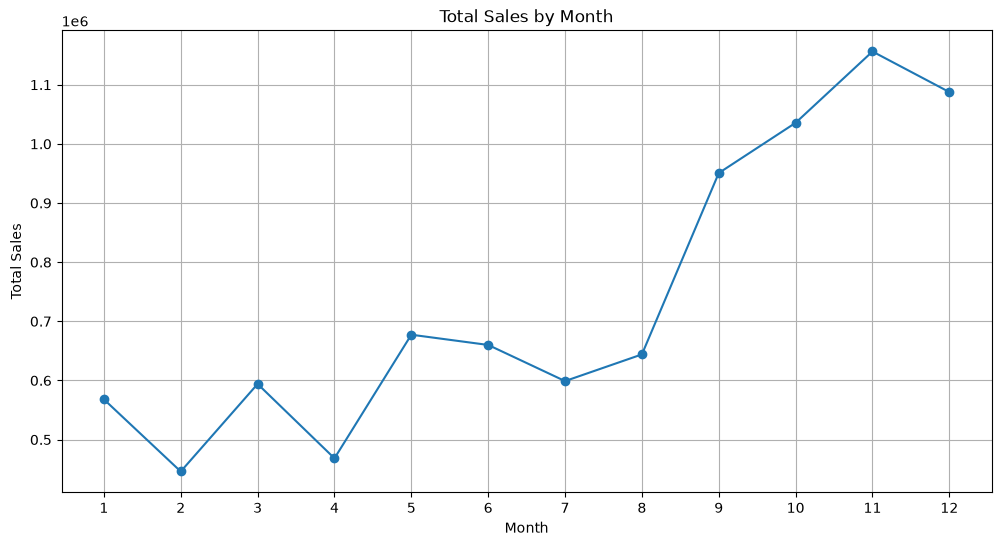

In [17]:
# Line chart

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data.groupby('month')['TotalPrice'].sum(), marker='o')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.grid()
plt.show()    

C:\Users\jeeva\AppData\Local\Temp\ipykernel_17428\939451207.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data['TotalPrice'], vert=False)


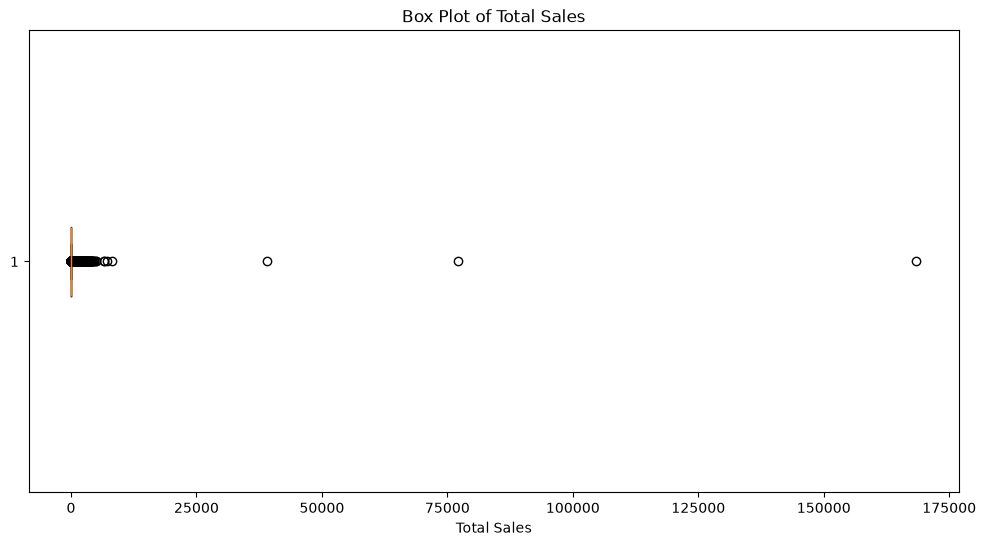

In [18]:
# Box plot

plt.figure(figsize=(12, 6))
plt.boxplot(data['TotalPrice'], vert=False)
plt.title('Box Plot of Total Sales')
plt.xlabel('Total Sales')
plt.show()

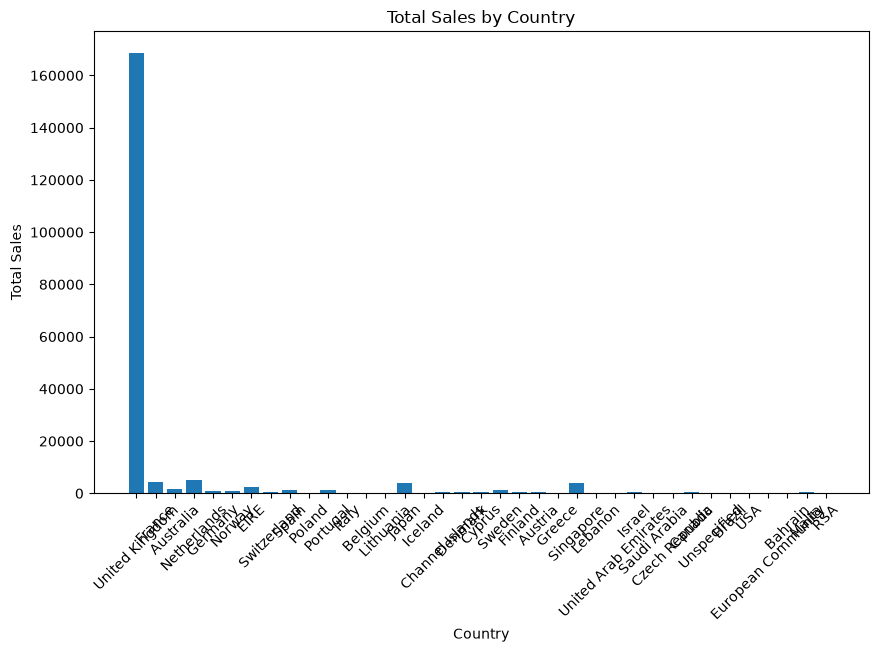

In [19]:
# Bar chart

plt.figure(figsize=(10, 6))
plt.bar(data['Country'], data['TotalPrice'])
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


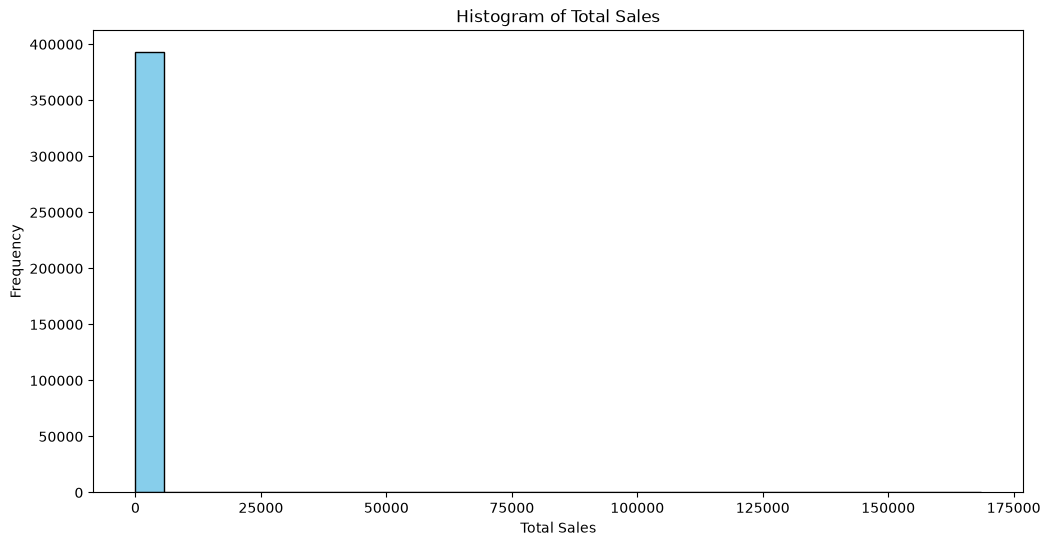

In [20]:
# Histogram

plt.figure(figsize=(12, 6))
plt.hist(data['TotalPrice'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

#### Seaborn:
● Count plot
● Violin plot
● Heatmap
● Pair plot

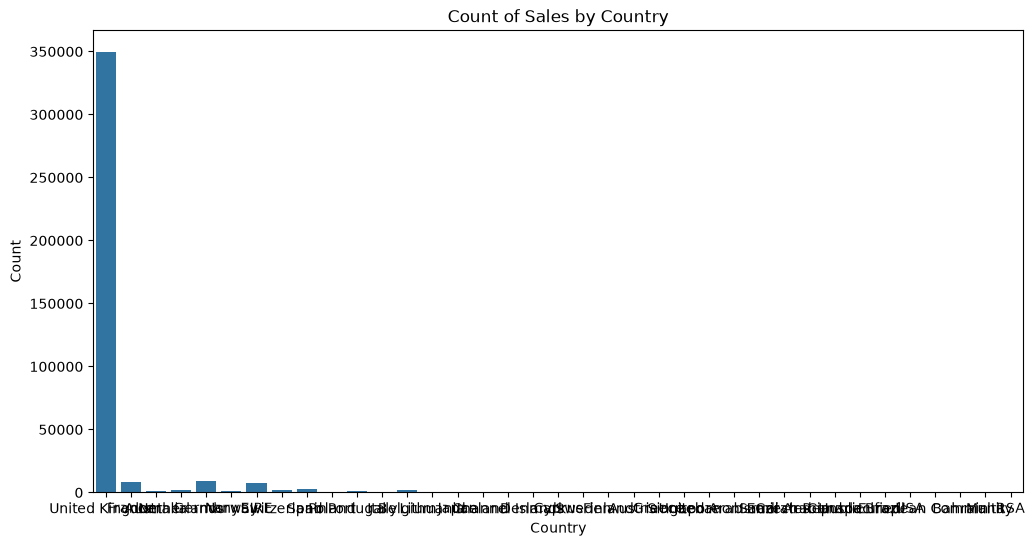

In [21]:
import seaborn as sns

# Count plot

plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Country')
plt.title('Count of Sales by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

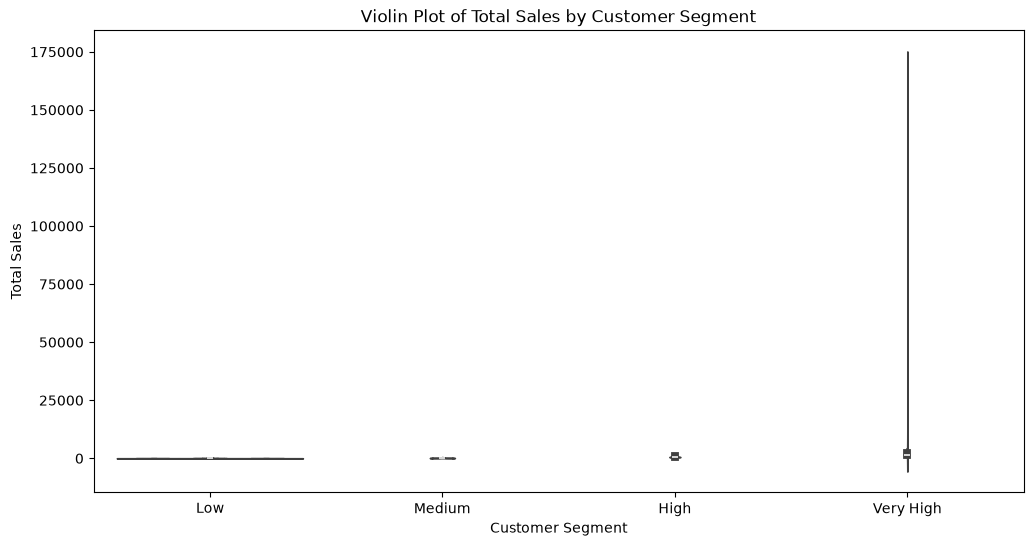

In [22]:
# Violin plot

plt.figure(figsize=(12, 6))
sns.violinplot(data=data, x='CustomerSegment', y='TotalPrice')
plt.title('Violin Plot of Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.show()


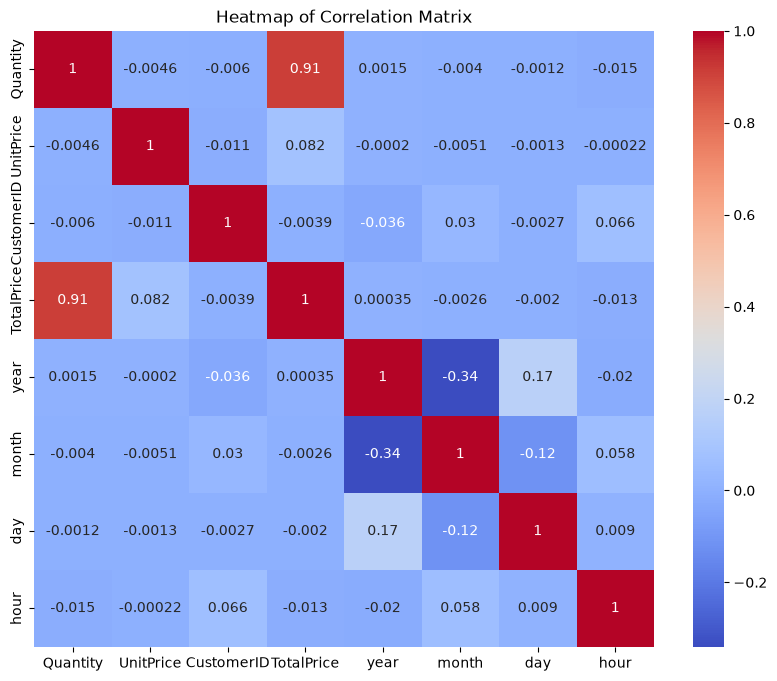

In [26]:
# Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation Matrix')
plt.show()

<Figure size 1200x600 with 0 Axes>

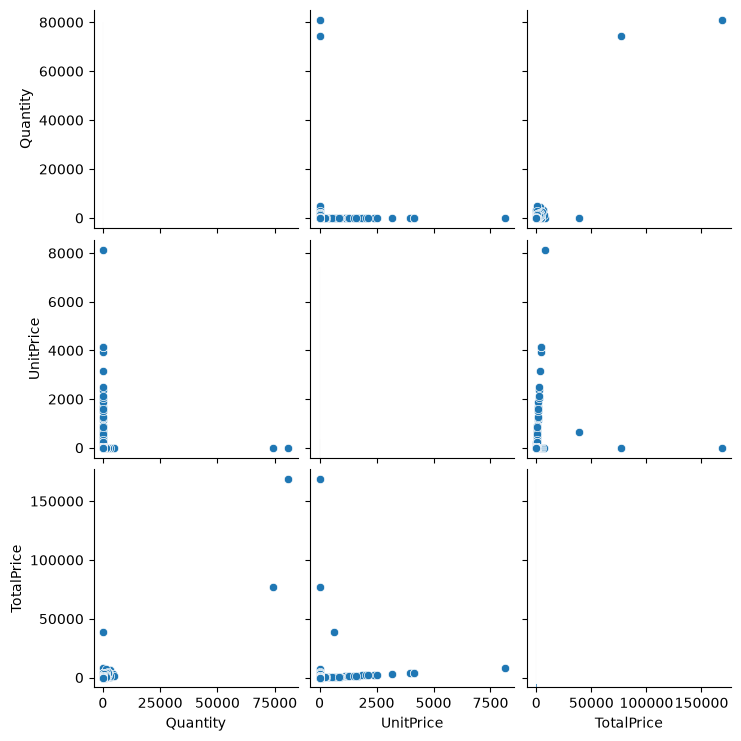

In [27]:
# Pair plot

plt.figure(figsize=(12, 6))
sns.pairplot(data[['Quantity', 'UnitPrice', 'TotalPrice']])
plt.show()

### Task 8 – Business Insights
#### ● Identify:
○ Top country
○ Best sales month
○ Peak sales time

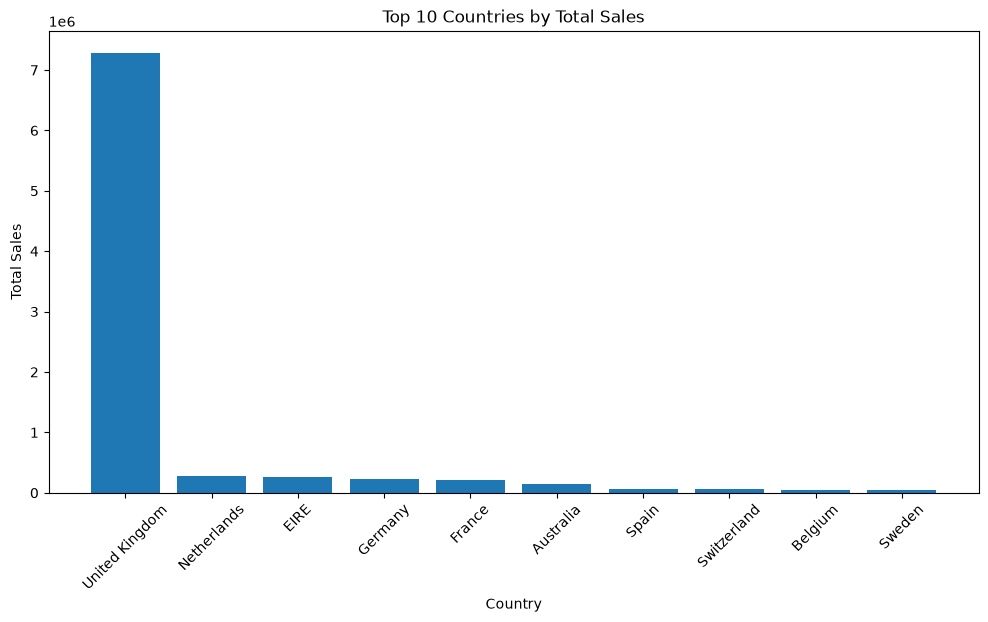

In [28]:
# Top country by total sales

plt.figure(figsize=(12, 6))
plt.bar(data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).index,
        data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).values)
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


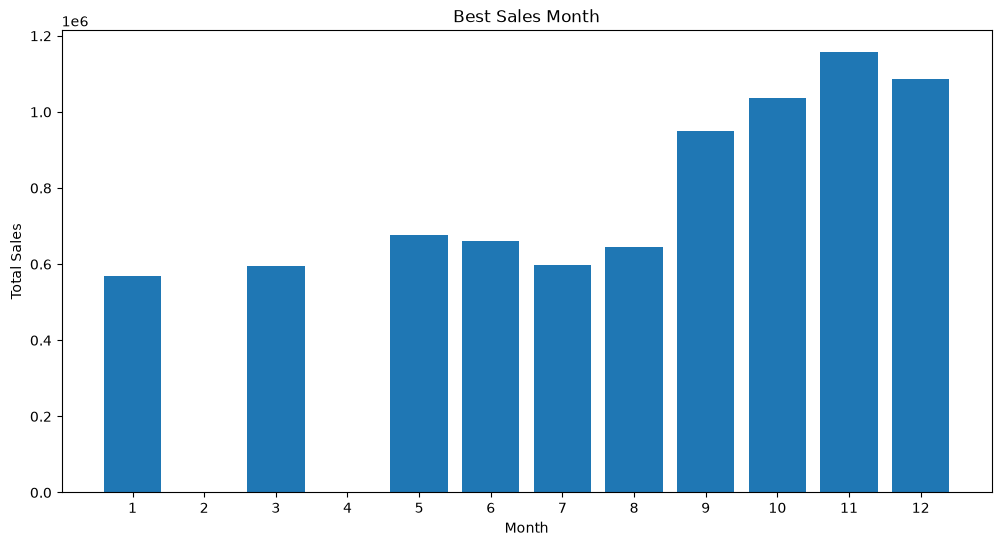

In [29]:
# Best sales month

plt.figure(figsize=(12, 6))
plt.bar(data.groupby('month')['TotalPrice'].sum().sort_values(ascending=False).head(10).index,
        data.groupby('month')['TotalPrice'].sum().sort_values(ascending=False).head(10).values)
plt.title('Best Sales Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.show()

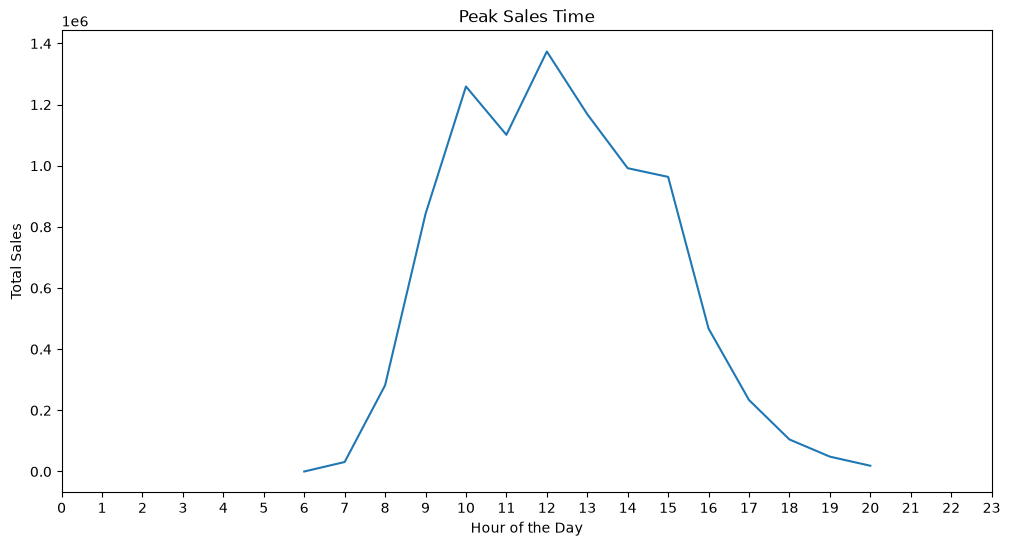

In [30]:
# Peak sales time

plt.figure(figsize=(12, 6))
plt.plot(data.groupby('hour')['TotalPrice'].sum().index, data.groupby('hour')['TotalPrice'].sum().values)
plt.title('Peak Sales Time')
plt.xlabel('Hour of the Day')   
plt.ylabel('Total Sales')
plt.xticks(range(0, 24))
plt.show()

#### ● Analyze:
○ Customer behavior
○ High-value customers
○ Top products



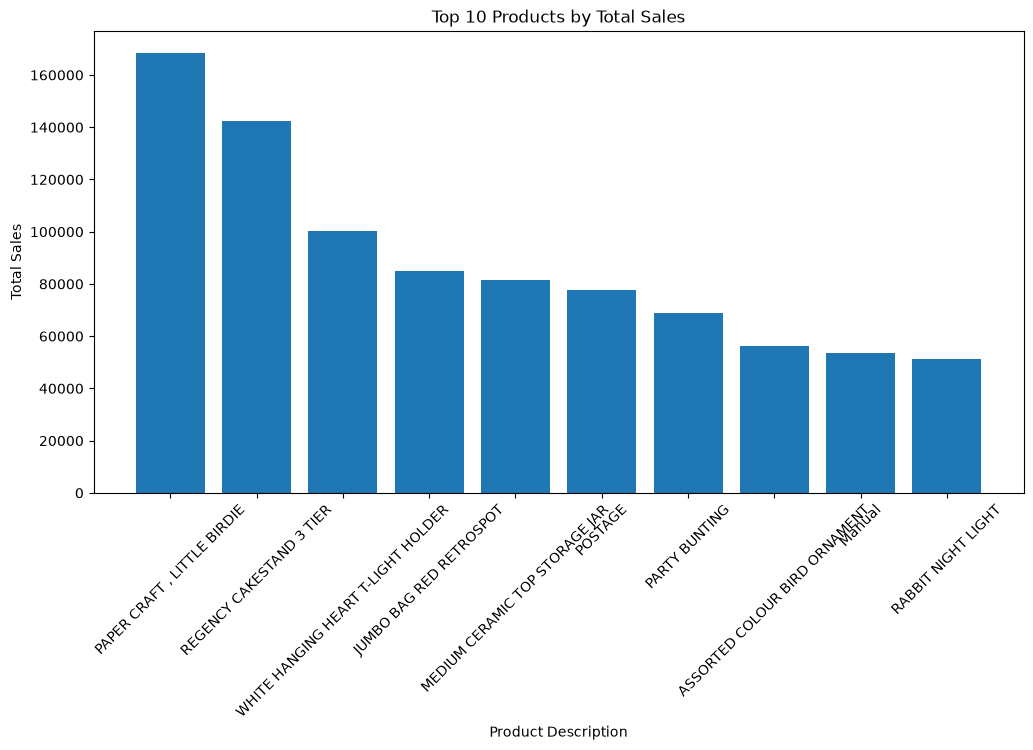

In [31]:
# Top products

plt.figure(figsize=(12, 6))
top_products = data.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.bar(top_products.index, top_products.values)
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Product Description')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

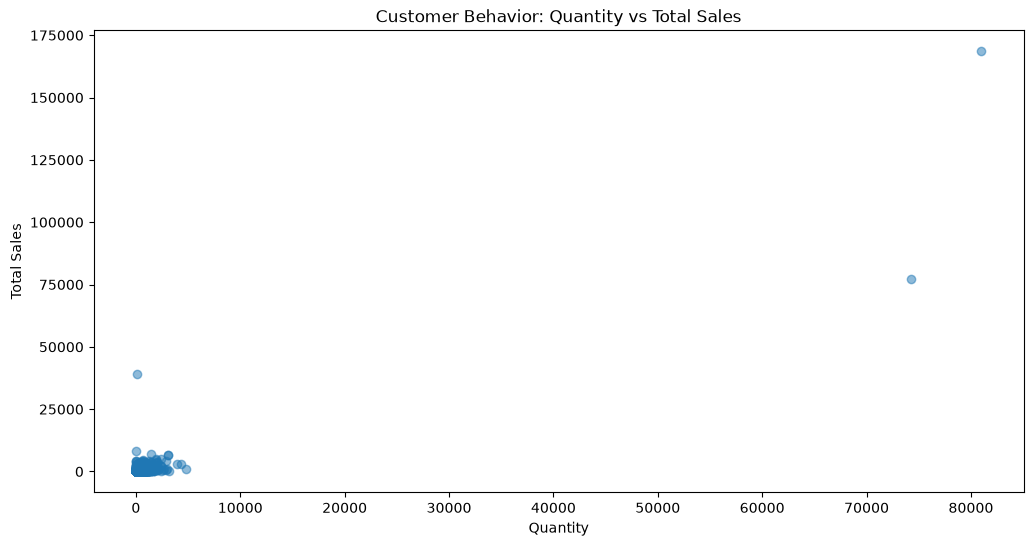

In [32]:
# Customer behavior except bar plot

plt.figure(figsize=(12, 6))
plt.scatter(data['Quantity'], data['TotalPrice'], alpha=0.5)
plt.title('Customer Behavior: Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()  

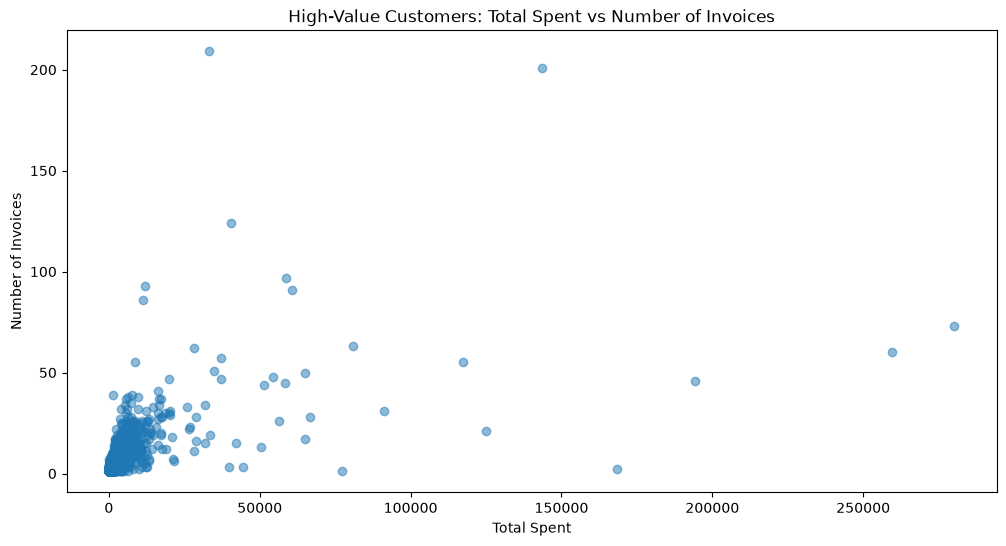

In [33]:
# High-value customers except bar plot and scatter plot

plt.figure(figsize=(12, 6))
plt.scatter(data_agg['TotalSpent'], data_agg['NumInvoices'], alpha=0.5)
plt.title('High-Value Customers: Total Spent vs Number of Invoices')
plt.xlabel('Total Spent')
plt.ylabel('Number of Invoices')
plt.show()